# Разведочный анализ данных: Household Power Consumption

EDA для временного ряда `household_power_consumption.txt`: базовая структура, пропуски, описательная статистика и визуализация основных временных рядов.


C:\Users\tetif\AppData\Local\Temp\ipykernel_19696\3522478030.py:17: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
C:\Users\tetif\AppData\Local\Temp\ipykernel_19696\3522478030.py:17: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(
C:\Users\tetif\AppData\Local\Temp\ipykernel_19696\3522478030.py:17: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


Форма датасета: (2075259, 8)


,datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0



Типы столбцов:
datetime                 datetime64[ns]
Global_active_power             float64
Global_reactive_power           float64
Voltage                         float64
Global_intensity                float64
Sub_metering_1                  float64
Sub_metering_2                  float64
Sub_metering_3                  float64
dtype: object

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   datetime               datetime64[ns]
 1   Global_active_power    float64       
 2   Global_reactive_power  float64       
 3   Voltage                float64       
 4   Global_intensity       float64       
 5   Sub_metering_1         float64       
 6   Sub_metering_2         float64       
 7   Sub_metering_3         float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 126.7 MB

Пропуски по столбцам:


Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


Описательная статистика числовых признаков:


,count,mean,std,min,25%,50%,75%,max
Global_active_power,2049280.0,1.091615,1.057294,0.076,0.308,0.602,1.528,11.122
Global_reactive_power,2049280.0,0.123714,0.112722,0.000,0.048,0.100,0.194,1.390
Voltage,2049280.0,240.839858,3.239987,223.200,238.990,241.010,242.890,254.150
Global_intensity,2049280.0,4.627759,4.444396,0.200,1.400,2.600,6.400,48.400
Sub_metering_1,2049280.0,1.121923,6.153031,0.000,0.000,0.000,0.000,88.000
Sub_metering_2,2049280.0,1.298520,5.822026,0.000,0.000,0.000,1.000,80.000
Sub_metering_3,2049280.0,6.458447,8.437154,0.000,0.000,1.000,17.000,31.000


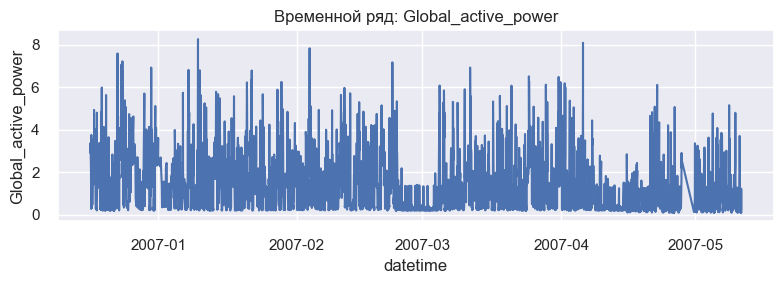

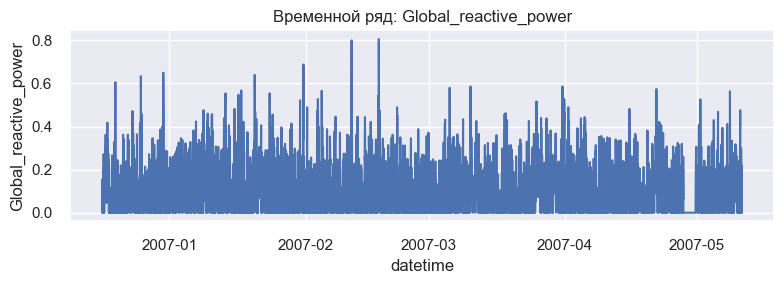

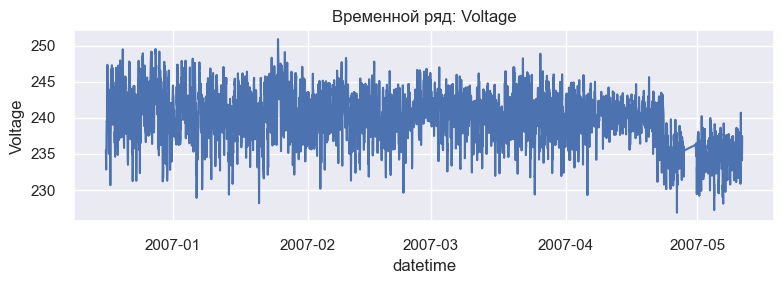

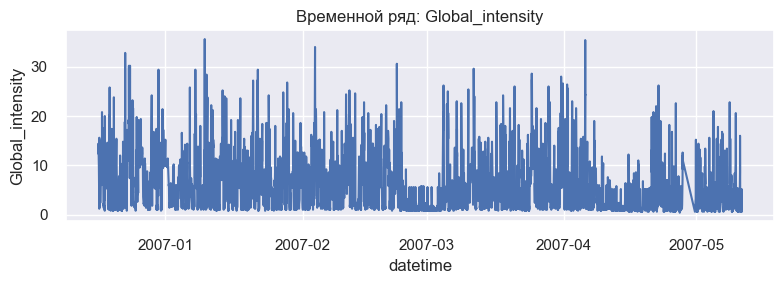

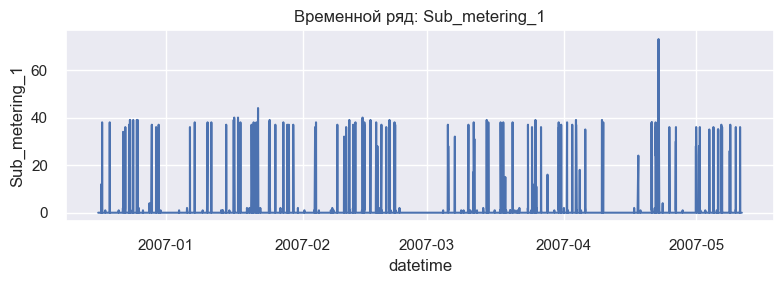

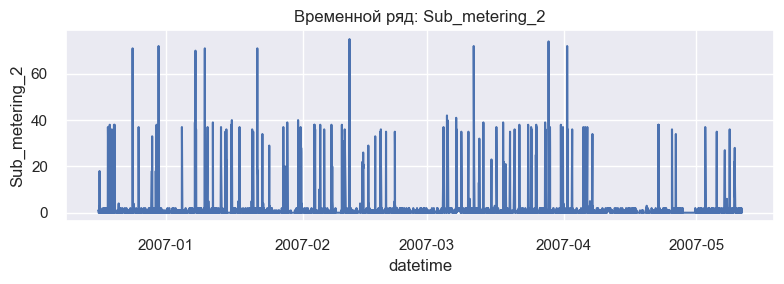

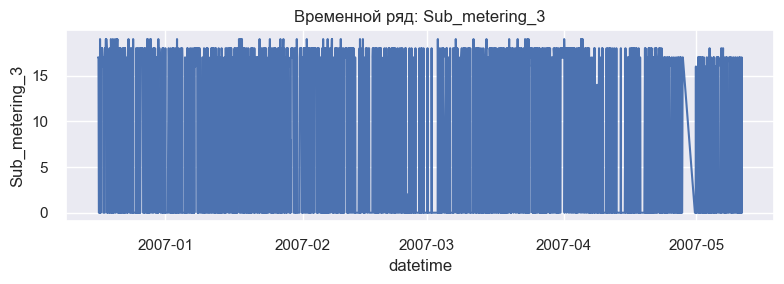

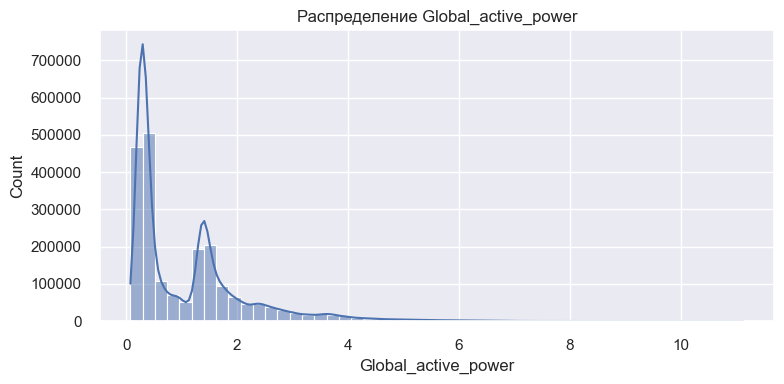

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use("seaborn-v0_8")
sns.set_theme()

DATA_PATH = os.path.join("..", "datasets", "electric", "household_power_consumption.txt")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

df = pd.read_csv(
    DATA_PATH,
    sep=";",
    na_values="?",
    parse_dates={"datetime": ["Date", "Time"]},
    infer_datetime_format=True,
    low_memory=False,
)

print("Форма датасета:", df.shape)
display(df.head())

print("\nТипы столбцов:")
print(df.dtypes)

print("\nИнформация о данных:")
df.info()

missing = df.isna().sum().sort_values(ascending=False)
print("\nПропуски по столбцам:")
display(missing[missing > 0])

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("\nОписательная статистика числовых признаков:")
display(df[numeric_cols].describe().T)

sample_df = df.dropna().sample(n=min(len(df), 50000), random_state=42)

for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.lineplot(x="datetime", y=col, data=sample_df.sort_values("datetime").iloc[:5000])
    plt.title(f"Временной ряд: {col}")
    plt.tight_layout()
    plt.show()

target_col = "Global_active_power"
if target_col in df.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[target_col].dropna(), bins=50, kde=True)
    plt.title("Распределение Global_active_power")
    plt.tight_layout()
    plt.show()
